In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error


In [2]:
# ====== Загрузка данных ======
df = pd.read_csv("social.csv")


In [3]:
target = "Healthcare_1"

# Признаки
features = ["Social_1", "Social_2", "Social_3",
            "Helthcare_2", "Price", "DistrictId"]


In [4]:
# ====== Разделение данных ======
train_df = df[df[target].notna()].copy()
test_df  = df[df[target].isna()].copy()

X_train = train_df[features]
y_train = train_df[target]
X_test  = test_df[features]

In [5]:
# ====== Модель Gradient Boosting ======
model = GradientBoostingRegressor(
    n_estimators=600,          # количество слабых моделей (деревьев)
    learning_rate=0.03,        # скорость обучения
    max_depth=3,               # глубина каждого дерева
    subsample=0.8,             # стохастический бустинг, уменьшает переобучение
    random_state=42
)

In [6]:
model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.03, n_estimators=600, random_state=42,
                          subsample=0.8)

In [7]:
# ====== Предсказания ======
preds = model.predict(X_test)

In [8]:
# Создаём финальную колонку
df["Healthcare_1_filled_GB"] = df["Healthcare_1"]
df.loc[df[target].isna(), "Healthcare_1_filled_GB"] = preds

print("Готово! Пропуски в Healthcare_1 заполнены колонкой Healthcare_1_filled_GB.")

Готово! Пропуски в Healthcare_1 заполнены колонкой Healthcare_1_filled_GB.


In [9]:
# ====== Оценка качества ======
train_pred = model.predict(X_train)

print("\n=== Оценка качества GradientBoostingRegressor ===")
print("R2:", r2_score(y_train, train_pred))
print("MAE:", mean_absolute_error(y_train, train_pred))


=== Оценка качества GradientBoostingRegressor ===
R2: 0.9866331552353951
MAE: 77.19603001490651


In [10]:
# ====== Важность признаков ======
importance = pd.Series(model.feature_importances_, index=features)
print("\nВажность признаков:")
print(importance.sort_values(ascending=False))


Важность признаков:
Social_2       0.327129
Social_3       0.243907
Social_1       0.210623
DistrictId     0.151588
Helthcare_2    0.066498
Price          0.000255
dtype: float64


In [13]:
df.head(20)

,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Price,DistrictId,Healthcare_1_filled_GB
0,33,7976,5,NaN,0,184966.930730,35,744.137611
1,46,10309,1,240.0,1,300009.450063,41,240.000000
2,34,7759,0,229.0,1,220925.908524,53,229.000000
3,23,5735,3,1084.0,0,175616.227217,58,1084.000000
4,35,5776,1,2078.0,2,150226.531644,99,2078.000000
5,35,7715,4,990.0,0,215898.447742,59,990.000000
6,20,4386,14,NaN,1,296021.204377,154,1552.245149
7,6,1437,3,NaN,0,221244.156664,74,118.274018
8,1,264,0,NaN,0,229102.795999,1,130.344112
9,6,1437,3,NaN,0,95380.220993,23,239.194422


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

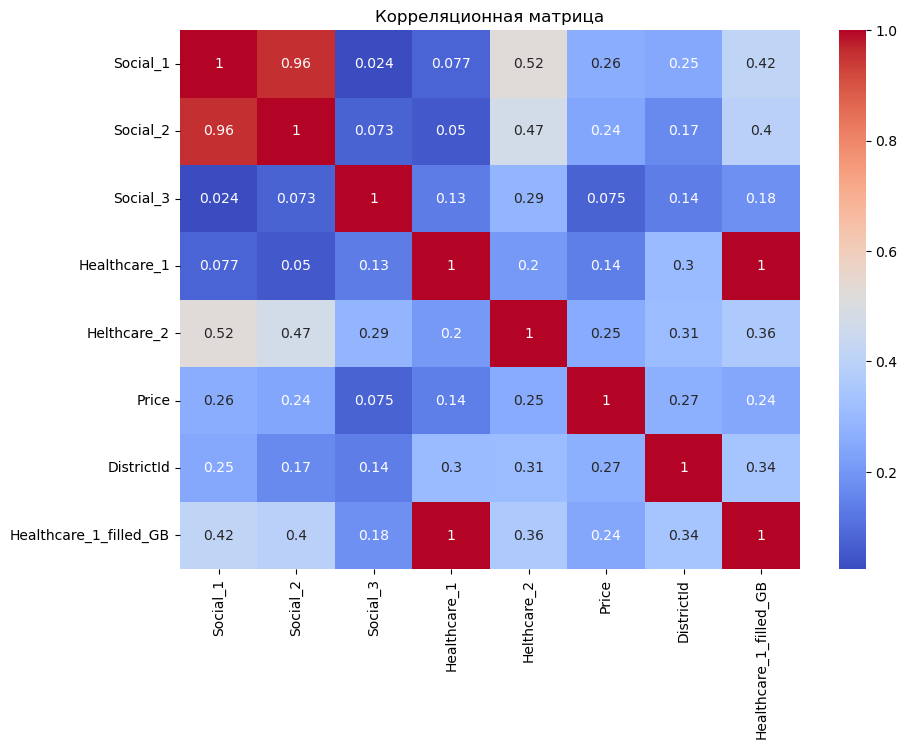

In [12]:
# --- Корреляции ---
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()